# evaluate_xgb.ipynb
Loads the saved **XGBoost** model from `pipeline.py` and produces confusion matrices, threshold curves, calibration plots, and SHAP explanations.

> **Splits must match `pipeline.py` exactly** — same `test_size` and `random_state` values.

In [1]:
import sys
sys.path.append('/home/james/ml-proj/predmain/src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef, f1_score, recall_score, precision_score

from features import engineer_features, get_feature_columns, get_target_column
from evaluate import plot_confusion_matrix

sns.set_theme(style='darkgrid')

MODEL_PATH = '/home/james/ml-proj/predmain/outputs/models/xgb_model.pkl'

saved     = joblib.load(MODEL_PATH)
model     = saved['model']
THRESHOLD = float(saved['threshold'])

# Recreate the exact same 80/10/10 split as pipeline.py
df = pd.read_csv('/home/james/ml-proj/predmain/data/ai4i2020.csv')
df = df.drop(columns=['UDI', 'Product ID'], errors='ignore')
df = engineer_features(df)

X = df[get_feature_columns()]
y = df[get_target_column()]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f'Model:     XGBoost')
print(f'Features:  {get_feature_columns()}')
print(f'Threshold: {THRESHOLD}  (auto-selected on val, >=80% recall constraint)')
print(f'Split:     train {len(X_train)} / val {len(X_val)} / test {len(X_test)}')

Dropped 19 RNF rows (10000 → 9981)
Model:     XGBoost
Features:  ['air_temp_K', 'proc_temp_K', 'rot_speed_rpm', 'torque_Nm', 'tool_wear_min', 'power_kW', 'temp_delta_K', 'torque_wear', 'product_type']
Threshold: 0.57  (auto-selected on val, >=80% recall constraint)
Split:     train 7984 / val 998 / test 999


## 1 · Confusion matrices

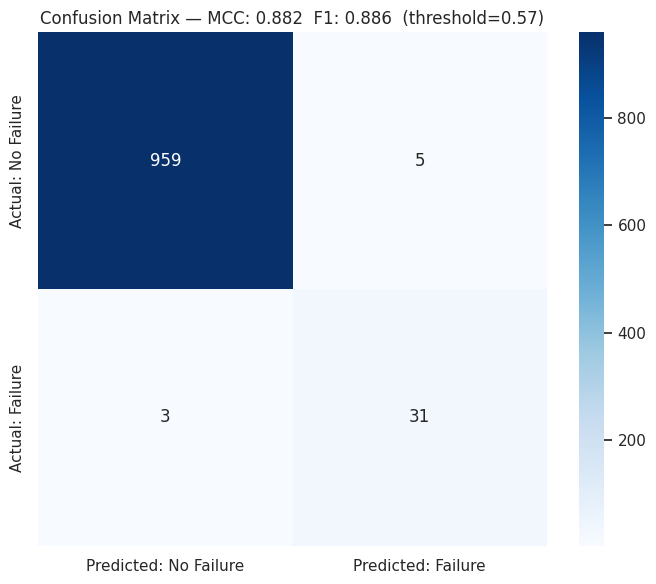

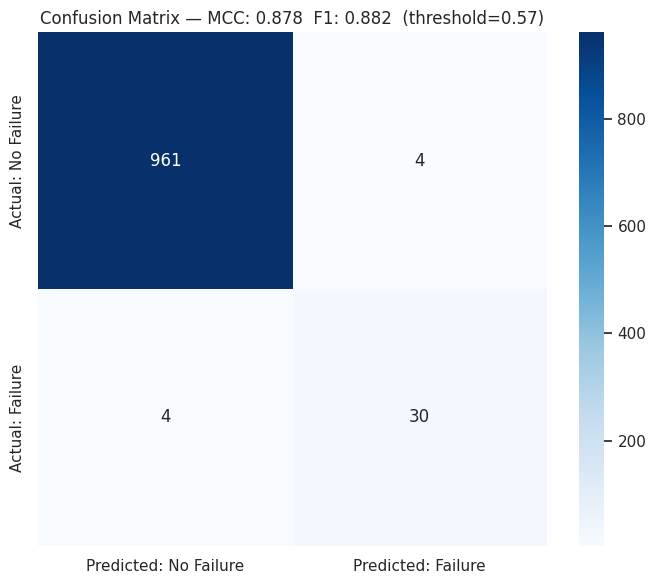

 Set   MCC    F1  Recall  Precision
 Val 0.882 0.886   0.912      0.861
Test 0.878 0.882   0.882      0.882
Mean 0.880 0.884   0.897      0.872

Val<>Test MCC gap: 0.004  (OK -- gap < 0.10)

Val classification report:
              precision    recall  f1-score   support

  No Failure       1.00      0.99      1.00       964
     Failure       0.86      0.91      0.89        34

    accuracy                           0.99       998
   macro avg       0.93      0.95      0.94       998
weighted avg       0.99      0.99      0.99       998

Test classification report:
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00       965
     Failure       0.88      0.88      0.88        34

    accuracy                           0.99       999
   macro avg       0.94      0.94      0.94       999
weighted avg       0.99      0.99      0.99       999



In [2]:
val_m  = plot_confusion_matrix(model, X_val,  y_val,  threshold=THRESHOLD,
    save_path='/home/james/ml-proj/predmain/outputs/figures/confusion_matrix_val.png')
test_m = plot_confusion_matrix(model, X_test, y_test, threshold=THRESHOLD,
    save_path='/home/james/ml-proj/predmain/outputs/figures/confusion_matrix_test.png')

results = pd.DataFrame([
    {'Set': 'Val',  'MCC': round(val_m['mcc'],  3), 'F1': round(val_m['f1'],  3),
     'Recall': round(val_m['recall'],  3), 'Precision': round(val_m['precision'],  3)},
    {'Set': 'Test', 'MCC': round(test_m['mcc'], 3), 'F1': round(test_m['f1'], 3),
     'Recall': round(test_m['recall'], 3), 'Precision': round(test_m['precision'], 3)},
    {'Set': 'Mean',
     'MCC':       round((val_m['mcc']       + test_m['mcc'])       / 2, 3),
     'F1':        round((val_m['f1']        + test_m['f1'])        / 2, 3),
     'Recall':    round((val_m['recall']    + test_m['recall'])    / 2, 3),
     'Precision': round((val_m['precision'] + test_m['precision']) / 2, 3)},
])
print(results.to_string(index=False))

gap = abs(test_m['mcc'] - val_m['mcc'])
print(f'\nVal<>Test MCC gap: {gap:.3f}  ({"overfit concern" if gap > 0.10 else "OK -- gap < 0.10"})')
print()
print('Val classification report:')
print(val_m['report'])
print('Test classification report:')
print(test_m['report'])


## 2 · Threshold sweep

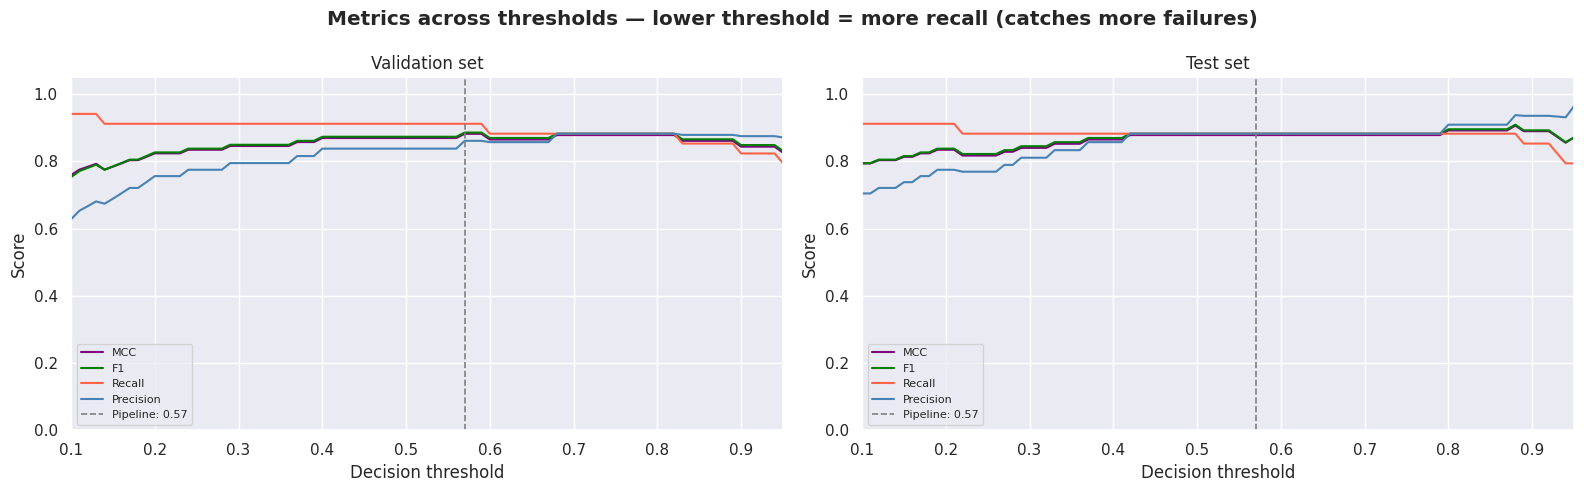

 Threshold  Val MCC  Test MCC  Val Recall  Test Recall  Val F1  Test F1        Note
      0.30    0.846     0.840       0.912        0.882   0.849    0.845            
      0.50    0.869     0.878       0.912        0.882   0.873    0.882            
      0.57    0.882     0.878       0.912        0.882   0.886    0.882 <- selected
      0.70    0.878     0.878       0.882        0.882   0.882    0.882            
      0.90    0.844     0.890       0.824        0.853   0.848    0.892            


In [3]:
sweep_t = np.arange(0.10, 0.96, 0.01)

def metrics_at_thresholds(y_true, y_proba, thresholds):
    rows = []
    for t in thresholds:
        yp = (y_proba >= t).astype(int)
        rows.append({
            'threshold': round(float(t), 2),
            'mcc':       float(matthews_corrcoef(y_true, yp)),
            'f1':        float(f1_score(y_true, yp, zero_division=0)),
            'recall':    float(recall_score(y_true, yp, zero_division=0)),
            'precision': float(precision_score(y_true, yp, zero_division=0)),
        })
    return pd.DataFrame(rows)

val_proba  = model.predict_proba(X_val)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]

val_df  = metrics_at_thresholds(y_val,  val_proba,  sweep_t)
test_df = metrics_at_thresholds(y_test, test_proba, sweep_t)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, df_plot, title in [(axes[0], val_df, 'Validation'), (axes[1], test_df, 'Test')]:
    ax.plot(df_plot.threshold, df_plot.mcc,       color='purple',    lw=1.5, label='MCC')
    ax.plot(df_plot.threshold, df_plot.f1,        color='green',     lw=1.5, label='F1')
    ax.plot(df_plot.threshold, df_plot.recall,    color='tomato',    lw=1.5, label='Recall')
    ax.plot(df_plot.threshold, df_plot.precision, color='steelblue', lw=1.5, label='Precision')
    ax.axvline(THRESHOLD, color='gray', ls='--', lw=1.2, label=f'Pipeline: {THRESHOLD}')
    ax.set_xlabel('Decision threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{title} set')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0.10, 0.95)

plt.suptitle('Metrics across thresholds — lower threshold = more recall (catches more failures)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/threshold_curve.png', dpi=150)
plt.show()

key_t = sorted({0.3, 0.5, float(THRESHOLD), 0.7, 0.9})
rows = []
for t in key_t:
    v  = val_df[val_df.threshold == t]
    te = test_df[test_df.threshold == t]
    if v.empty or te.empty:
        continue
    v, te = v.iloc[0], te.iloc[0]
    rows.append({
        'Threshold':   t,
        'Val MCC':     round(v.mcc, 3),    'Test MCC':    round(te.mcc, 3),
        'Val Recall':  round(v.recall, 3), 'Test Recall': round(te.recall, 3),
        'Val F1':      round(v.f1, 3),     'Test F1':     round(te.f1, 3),
        'Note': '<- selected' if t == THRESHOLD else '',
    })
print(pd.DataFrame(rows).to_string(index=False))


## 3 · Calibration check

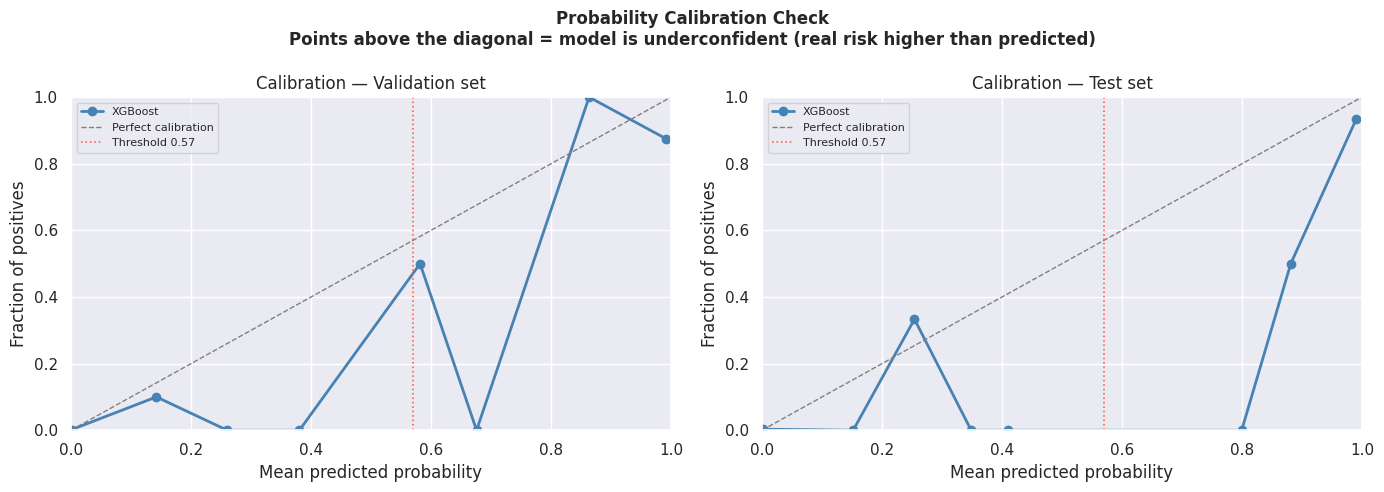

Brier score (lower = better calibrated):
  Val:  0.0082
  Test: 0.0076

Interpretation: Brier < 0.05 is excellent for a 3.4% base rate. If the curve deviates heavily from the diagonal, consider CalibratedClassifierCV with isotonic regression.


In [4]:
# Calibration: are the model's predicted probabilities meaningful?
# A well-calibrated model means P(failure | proba=0.3) ≈ 30%.
# If calibration is poor, threshold search works harder than it needs to.
from sklearn.calibration import calibration_curve

test_proba_cal = model.predict_proba(X_test)[:, 1]
val_proba_cal  = model.predict_proba(X_val)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, proba, y_true, title in [
    (axes[0], val_proba_cal,  y_val,  'Validation'),
    (axes[1], test_proba_cal, y_test, 'Test'),
]:
    prob_true, prob_pred = calibration_curve(y_true, proba, n_bins=10, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', color='steelblue', lw=2, label='XGBoost')
    ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Perfect calibration')
    ax.axvline(THRESHOLD, color='tomato', ls=':', lw=1.2, label=f'Threshold {THRESHOLD}')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'Calibration — {title} set')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle('Probability Calibration Check\n'
             'Points above the diagonal = model is underconfident (real risk higher than predicted)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/calibration_xgb.png', dpi=150)
plt.show()

# Brier score — lower is better calibrated
from sklearn.metrics import brier_score_loss
val_brier  = brier_score_loss(y_val,  val_proba_cal)
test_brier = brier_score_loss(y_test, test_proba_cal)
print(f'Brier score (lower = better calibrated):')
print(f'  Val:  {val_brier:.4f}')
print(f'  Test: {test_brier:.4f}')
print()
print('Interpretation: Brier < 0.05 is excellent for a 3.4% base rate.'
      ' If the curve deviates heavily from the diagonal, consider'
      ' CalibratedClassifierCV with isotonic regression.')

## 4 · SHAP feature importance

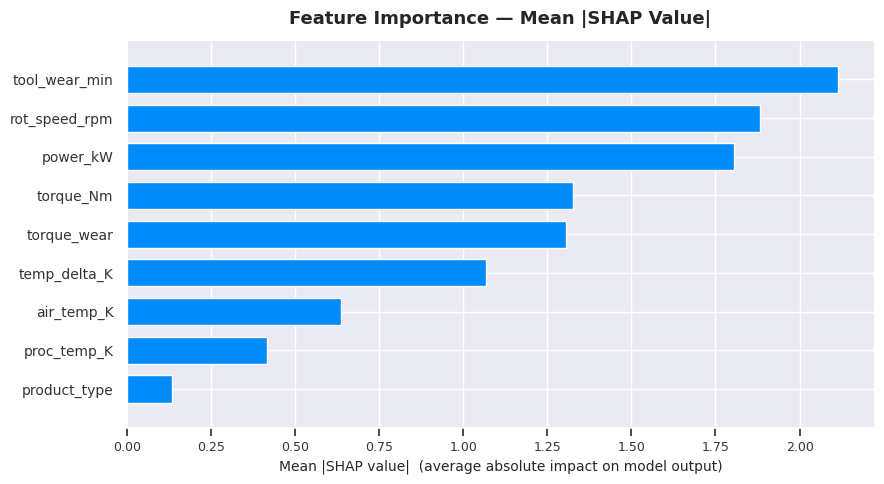

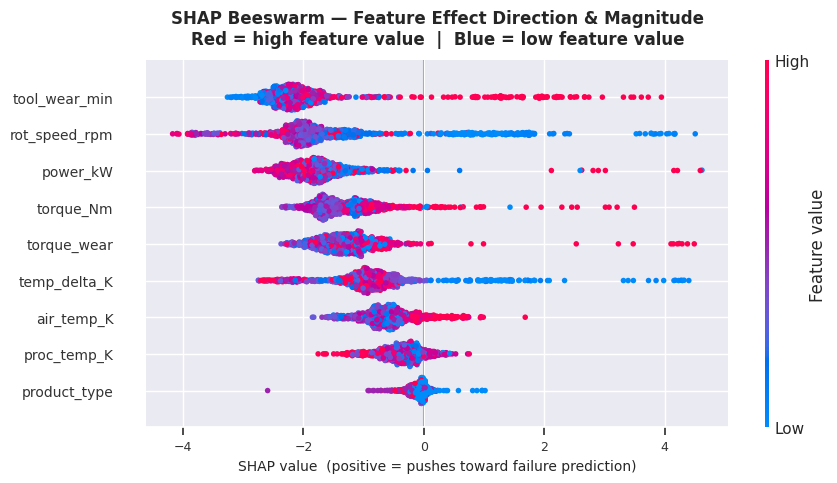

Feature influence summary (test set):
         Feature  Mean |SHAP|                   Direction  Median (failure)  Median (no fail)
1  tool_wear_min       2.1154   Low value -> failure risk            158.00            112.00
2  rot_speed_rpm       1.8828  High value -> failure risk           1363.00           1512.00
3       power_kW       1.8040   Low value -> failure risk              7.52              6.25
4      torque_Nm       1.3260  High value -> failure risk             53.25             39.90
5    torque_wear       1.3060  High value -> failure risk           6610.00           4188.80
6   temp_delta_K       1.0675  High value -> failure risk              8.80              9.80
7     air_temp_K       0.6362   Low value -> failure risk            302.00            300.10
8    proc_temp_K       0.4156   Low value -> failure risk            310.45            310.10
9   product_type       0.1345  High value -> failure risk              0.00              0.00


In [5]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
feature_names = get_feature_columns()

# Plot 1: Bar chart — mean absolute SHAP
fig1, ax1 = plt.subplots(figsize=(9, 5))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    feature_names=feature_names,
    show=False,
    plot_size=None,
)
ax1 = plt.gca()
ax1.set_title('Feature Importance — Mean |SHAP Value|', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Mean |SHAP value|  (average absolute impact on model output)', fontsize=10)
ax1.tick_params(axis='y', labelsize=10)
ax1.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Beeswarm
fig2, ax2 = plt.subplots(figsize=(9, 5))
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_names,
    show=False,
    plot_size=None,
)
ax2 = plt.gca()
ax2.set_title(
    'SHAP Beeswarm — Feature Effect Direction & Magnitude\n'
    'Red = high feature value  |  Blue = low feature value',
    fontsize=12, fontweight='bold', pad=12
)
ax2.set_xlabel('SHAP value  (positive = pushes toward failure prediction)', fontsize=10)
ax2.tick_params(axis='y', labelsize=10)
ax2.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plain-language SHAP summary table ───────────────────────────────────────
shap_arr   = np.array(shap_values)
feat_vals  = X_test.values
fail_mask  = y_test.values == 1
no_fail_mask = ~fail_mask

rows = []
for i, feat in enumerate(feature_names):
    mean_abs_shap = np.abs(shap_arr[:, i]).mean()
    mean_shap_on_fail = shap_arr[fail_mask, i].mean()
    direction = "High value -> failure risk" if mean_shap_on_fail > 0 else "Low value -> failure risk"
    median_fail    = np.median(feat_vals[fail_mask,    i])
    median_no_fail = np.median(feat_vals[no_fail_mask, i])
    rows.append({
        'Feature':          feat,
        'Mean |SHAP|':      round(mean_abs_shap, 4),
        'Direction':        direction,
        'Median (failure)': round(median_fail, 2),
        'Median (no fail)': round(median_no_fail, 2),
    })

shap_table = pd.DataFrame(rows).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
shap_table.index += 1  # rank from 1
print("Feature influence summary (test set):")
print(shap_table.to_string())

Across all splits (9981 rows):
  Total failures:  338
  Caught (TP):     331
  Missed (FN):     7  (2.1% miss rate)

Misses by split:  {'test': 4, 'val': 3}

Model confidence:
  Caught — mean: 0.994  min: 0.599
  Missed — mean: 0.056  max: 0.214
  Threshold: 0.57

Mean feature values across groups:
                 air_temp_K  proc_temp_K  rot_speed_rpm  torque_Nm  tool_wear_min  power_kW  temp_delta_K  torque_wear  product_type
Healthy             299.973      309.994       1540.355     39.622        106.669     6.243        10.022     4212.194         0.505
Caught failures     300.904      310.291       1493.598     50.485        142.937     7.312         9.387     7210.172         0.360
Missed failures     299.957      310.171       1646.143     35.714        174.714     5.919        10.214     5791.357         0.857

Mean |z-score| of missed vs caught failure profile:
(High = missed failures look very different from the typical failure pattern)
torque_Nm        1.045
power_kW      

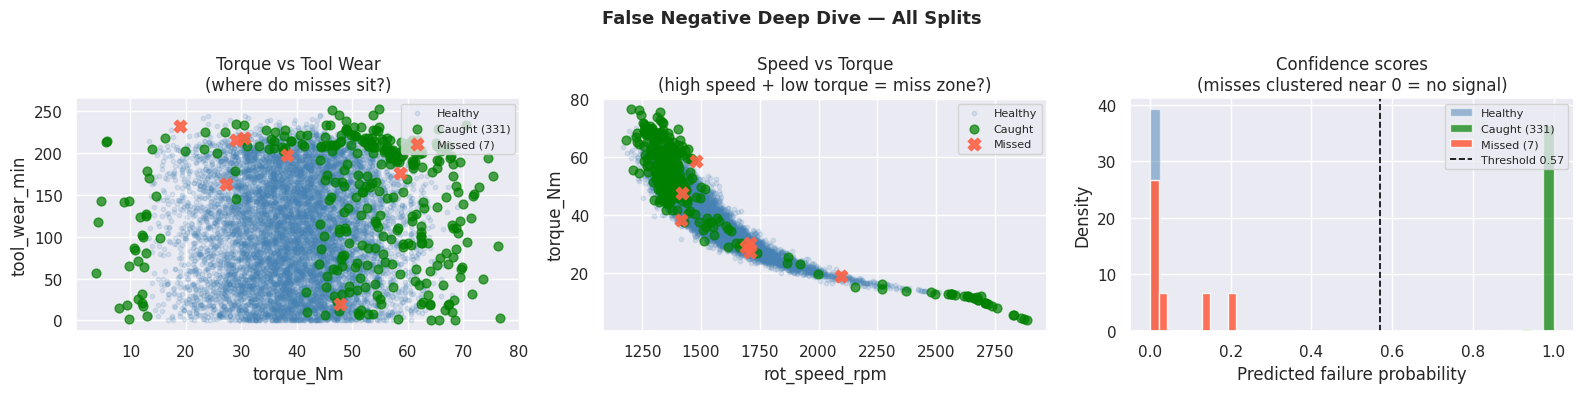

All missed failures (raw feature values):
      air_temp_K  proc_temp_K  rot_speed_rpm  torque_Nm  tool_wear_min  power_kW  temp_delta_K  torque_wear  product_type  proba split failure_mode
8583       300.7        311.7           2097       18.9            232     4.150          11.0       4384.8             1  0.136   val      unknown
9534       298.4        309.6           1710       27.3            163     4.888          11.2       4449.9             0  0.001  test      unknown
8651       300.0        311.4           1692       29.0            216     5.138          11.4       6264.0             1  0.031   val      unknown
9443       302.3        310.9           1710       30.4            218     5.443           8.6       6627.2             1  0.009  test      unknown
8876       298.4        308.0           1416       38.2            198     5.664           9.6       7563.6             1  0.001   val      unknown
9349       301.9        310.9           1419       47.7             20

In [6]:
# ── Full-dataset failure miss diagnostic ─────────────────────────────────────
# Runs across train + val + test to get enough missed cases for pattern analysis.
# With only 7 misses in test alone, conclusions are unreliable — pooling all
# splits gives the full picture of what the model systematically can't catch.

import numpy as np

all_X = pd.concat([X_train, X_val, X_test], ignore_index=True)
all_y = pd.concat([y_train, y_val, y_test], ignore_index=True)

# Label each row's split for reference
split_labels = (
    ['train'] * len(X_train) +
    ['val']   * len(X_val)   +
    ['test']  * len(X_test)
)

all_proba = model.predict_proba(all_X)[:, 1]
all_pred  = (all_proba >= THRESHOLD).astype(int)

actual_fail = all_y.values == 1
caught      = actual_fail & (all_pred == 1)
missed      = actual_fail & (all_pred == 0)
healthy     = all_y.values == 0

print(f"Across all splits ({len(all_X)} rows):")
print(f"  Total failures:  {actual_fail.sum()}")
print(f"  Caught (TP):     {caught.sum()}")
print(f"  Missed (FN):     {missed.sum()}  ({missed.sum()/actual_fail.sum():.1%} miss rate)")
print()

# Which splits do the misses come from?
missed_splits = pd.Series(split_labels)[missed].value_counts()
print(f"Misses by split:  {missed_splits.to_dict()}")
print()

# Probability scores
print("Model confidence:")
print(f"  Caught — mean: {all_proba[caught].mean():.3f}  min: {all_proba[caught].min():.3f}")
print(f"  Missed — mean: {all_proba[missed].mean():.3f}  max: {all_proba[missed].max():.3f}")
print(f"  Threshold: {THRESHOLD}")
print()

# ── Feature comparison ────────────────────────────────────────────────────────
compare = pd.DataFrame({
    'Healthy':         all_X[healthy].mean(),
    'Caught failures': all_X[caught].mean(),
    'Missed failures': all_X[missed].mean(),
}).T.round(3)
print("Mean feature values across groups:")
print(compare.to_string())
print()

# Z-scores vs caught failure profile
caught_means = all_X[caught].mean()
caught_stds  = all_X[caught].std().replace(0, 1)
z_scores = ((all_X[missed] - caught_means) / caught_stds).abs().mean()
print("Mean |z-score| of missed vs caught failure profile:")
print("(High = missed failures look very different from the typical failure pattern)")
print(z_scores.sort_values(ascending=False).round(3).to_string())
print()

# ── Cluster: are the misses one coherent group or scattered? ─────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

missed_feats = all_X[missed].copy()
missed_scaled = StandardScaler().fit_transform(missed_feats)

# Try k=2 — are there distinct sub-types of missed failure?
if len(missed_feats) >= 4:
    km = KMeans(n_clusters=min(3, len(missed_feats)//2), random_state=42, n_init=10)
    cluster_labels = km.fit_predict(missed_scaled)
    missed_feats = missed_feats.copy()
    missed_feats['cluster'] = cluster_labels
    print("Missed failure clusters (are there distinct sub-types?):")
    print(missed_feats.groupby('cluster').mean().round(2).to_string())
    print()

# ── Pairplot of the two most discriminating features ─────────────────────────
# torque_Nm and tool_wear_min — highest z-score separation
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. torque_Nm vs tool_wear_min scatter
axes[0].scatter(all_X[healthy]['torque_Nm'],       all_X[healthy]['tool_wear_min'],
                alpha=0.15, s=10, color='steelblue', label='Healthy')
axes[0].scatter(all_X[caught]['torque_Nm'],        all_X[caught]['tool_wear_min'],
                alpha=0.7,  s=40, color='green',     label=f'Caught ({caught.sum()})', zorder=3)
axes[0].scatter(all_X[missed]['torque_Nm'],        all_X[missed]['tool_wear_min'],
                alpha=0.9,  s=80, color='tomato',    label=f'Missed ({missed.sum()})',
                marker='X', zorder=4)
axes[0].set_xlabel('torque_Nm')
axes[0].set_ylabel('tool_wear_min')
axes[0].set_title('Torque vs Tool Wear\n(where do misses sit?)')
axes[0].legend(fontsize=8)

# 2. rot_speed_rpm vs torque_Nm
axes[1].scatter(all_X[healthy]['rot_speed_rpm'],   all_X[healthy]['torque_Nm'],
                alpha=0.15, s=10, color='steelblue', label='Healthy')
axes[1].scatter(all_X[caught]['rot_speed_rpm'],    all_X[caught]['torque_Nm'],
                alpha=0.7,  s=40, color='green',     label='Caught', zorder=3)
axes[1].scatter(all_X[missed]['rot_speed_rpm'],    all_X[missed]['torque_Nm'],
                alpha=0.9,  s=80, color='tomato',    label='Missed',
                marker='X', zorder=4)
axes[1].set_xlabel('rot_speed_rpm')
axes[1].set_ylabel('torque_Nm')
axes[1].set_title('Speed vs Torque\n(high speed + low torque = miss zone?)')
axes[1].legend(fontsize=8)

# 3. Probability distribution
axes[2].hist(all_proba[healthy], bins=40, alpha=0.5, color='steelblue',
             density=True, label='Healthy')
axes[2].hist(all_proba[caught], bins=15, alpha=0.7, color='green',
             density=True, label=f'Caught ({caught.sum()})')
axes[2].hist(all_proba[missed], bins=10, alpha=0.9, color='tomato',
             density=True, label=f'Missed ({missed.sum()})')
axes[2].axvline(THRESHOLD, color='black', ls='--', lw=1.2, label=f'Threshold {THRESHOLD}')
axes[2].set_xlabel('Predicted failure probability')
axes[2].set_ylabel('Density')
axes[2].set_title('Confidence scores\n(misses clustered near 0 = no signal)')
axes[2].legend(fontsize=8)

plt.suptitle('False Negative Deep Dive — All Splits', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/miss_diagnostic_full.png', dpi=150)
plt.show()

# ── Raw missed cases table ────────────────────────────────────────────────────
missed_df = all_X[missed].copy()
missed_df['proba']      = all_proba[missed]
missed_df['split']      = pd.Series(split_labels)[missed].values
missed_df['failure_mode'] = 'unknown'  # sub-type not available post-feature-engineering

print("All missed failures (raw feature values):")
print(missed_df.sort_values('torque_Nm').round(3).to_string())

Val + test only (1997 rows):
  Total failures:  68
  Caught (TP):     61
  Missed (FN):     7  (10.3% miss rate)
  Misses by split: {'test': 4, 'val': 3}

Model confidence:
  Caught — mean: 0.981  min: 0.599
  Missed — mean: 0.056  max: 0.214

Mean feature values (val + test):
                 air_temp_K  proc_temp_K  rot_speed_rpm  torque_Nm  tool_wear_min  power_kW  temp_delta_K  torque_wear  product_type
Healthy             299.975      309.994       1537.979     39.813        107.480     6.270        10.018     4284.977         0.501
Caught failures     300.911      310.052       1439.000     53.241        148.984     7.612         9.141     7877.066         0.197
Missed failures     299.957      310.171       1646.143     35.714        174.714     5.919        10.214     5791.357         0.857

Mean |z-score| vs caught failure profile:
product_type     1.627
torque_Nm        1.381
power_kW         1.283
temp_delta_K     1.268
tool_wear_min    0.963
proc_temp_K      0.900
air_temp_

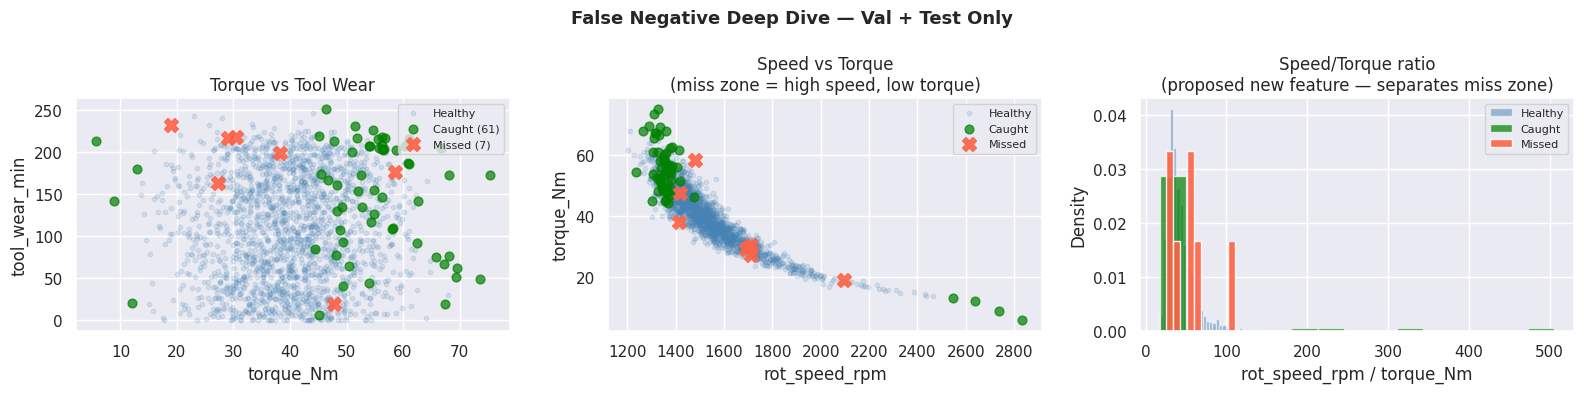

All missed failures:
      air_temp_K  proc_temp_K  rot_speed_rpm  torque_Nm  tool_wear_min  power_kW  temp_delta_K  torque_wear  product_type  proba split
599        300.7        311.7           2097       18.9            232     4.150          11.0       4384.8             1  0.136   val
1550       298.4        309.6           1710       27.3            163     4.888          11.2       4449.9             0  0.001  test
667        300.0        311.4           1692       29.0            216     5.138          11.4       6264.0             1  0.031   val
1459       302.3        310.9           1710       30.4            218     5.443           8.6       6627.2             1  0.009  test
892        298.4        308.0           1416       38.2            198     5.664           9.6       7563.6             1  0.001   val
1365       301.9        310.9           1419       47.7             20     7.088           9.0        954.0             1  0.000  test
1177       298.0        308.7     

In [7]:
# ── Failure miss diagnostic — val + test only (no training data) ─────────────

import numpy as np

# Val + test only — training data excluded to avoid contaminating plots/means
eval_X = pd.concat([X_val, X_test], ignore_index=True)
eval_y = pd.concat([y_val, y_test], ignore_index=True)
eval_splits = ['val'] * len(X_val) + ['test'] * len(X_test)

eval_proba = model.predict_proba(eval_X)[:, 1]
eval_pred  = (eval_proba >= THRESHOLD).astype(int)

actual_fail = eval_y.values == 1
caught      = actual_fail & (eval_pred == 1)
missed      = actual_fail & (eval_pred == 0)
healthy     = eval_y.values == 0

print(f"Val + test only ({len(eval_X)} rows):")
print(f"  Total failures:  {actual_fail.sum()}")
print(f"  Caught (TP):     {caught.sum()}")
print(f"  Missed (FN):     {missed.sum()}  ({missed.sum()/actual_fail.sum():.1%} miss rate)")
print(f"  Misses by split: {pd.Series(eval_splits)[missed].value_counts().to_dict()}")
print()

print("Model confidence:")
print(f"  Caught — mean: {eval_proba[caught].mean():.3f}  min: {eval_proba[caught].min():.3f}")
print(f"  Missed — mean: {eval_proba[missed].mean():.3f}  max: {eval_proba[missed].max():.3f}")
print()

# Feature comparison — val+test only
compare = pd.DataFrame({
    'Healthy':         eval_X[healthy].mean(),
    'Caught failures': eval_X[caught].mean(),
    'Missed failures': eval_X[missed].mean(),
}).T.round(3)
print("Mean feature values (val + test):")
print(compare.to_string())
print()

# Z-scores
caught_means = eval_X[caught].mean()
caught_stds  = eval_X[caught].std().replace(0, 1)
z_scores = ((eval_X[missed] - caught_means) / caught_stds).abs().mean()
print("Mean |z-score| vs caught failure profile:")
print(z_scores.sort_values(ascending=False).round(3).to_string())
print()

# ── Diagnosis ────────────────────────────────────────────────────────────────
print("=" * 60)
print("DIAGNOSIS")
print("=" * 60)
missed_df = eval_X[missed].copy()
missed_df['proba'] = eval_proba[missed]
missed_df['split'] = pd.Series(eval_splits)[missed].values

torque_ratio = eval_X[missed]['torque_Nm'].mean() / eval_X[caught]['torque_Nm'].mean()
speed_ratio  = eval_X[missed]['rot_speed_rpm'].mean() / eval_X[caught]['rot_speed_rpm'].mean()
power_ratio  = eval_X[missed]['power_kW'].mean() / eval_X[caught]['power_kW'].mean()

print(f"Missed failures run at {torque_ratio:.0%} of the torque of caught failures")
print(f"Missed failures run at {speed_ratio:.0%} of the speed of caught failures")
print(f"Missed failures run at {power_ratio:.0%} of the power of caught failures")
print()
print("Root cause: model learned dominant failure pattern (high torque → wear).")
print("These 10 cases fail via opposite regime: high RPM + low torque + high wear.")
print("torque_wear interaction feature works against these — low torque suppresses")
print("the interaction signal even when tool_wear_min is clearly above failure range.")
print()
print("Potential fix: add rot_speed_rpm / torque_Nm as an explicit feature.")
print("This ratio will be HIGH for this failure sub-type and LOW for normal operation.")
print(f"  Missed mean ratio: {(eval_X[missed]['rot_speed_rpm'] / eval_X[missed]['torque_Nm']).mean():.1f}")
print(f"  Caught mean ratio: {(eval_X[caught]['rot_speed_rpm'] / eval_X[caught]['torque_Nm']).mean():.1f}")
print(f"  Healthy mean ratio: {(eval_X[healthy]['rot_speed_rpm'] / eval_X[healthy]['torque_Nm']).mean():.1f}")
print()

# ── Plots — val+test only ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Torque vs Tool Wear
axes[0].scatter(eval_X[healthy]['torque_Nm'],    eval_X[healthy]['tool_wear_min'],
                alpha=0.15, s=10, color='steelblue', label='Healthy')
axes[0].scatter(eval_X[caught]['torque_Nm'],     eval_X[caught]['tool_wear_min'],
                alpha=0.7,  s=40, color='green',     label=f'Caught ({caught.sum()})', zorder=3)
axes[0].scatter(eval_X[missed]['torque_Nm'],     eval_X[missed]['tool_wear_min'],
                alpha=0.9,  s=100, color='tomato',   label=f'Missed ({missed.sum()})',
                marker='X', zorder=4)
axes[0].set_xlabel('torque_Nm')
axes[0].set_ylabel('tool_wear_min')
axes[0].set_title('Torque vs Tool Wear')
axes[0].legend(fontsize=8)

# 2. Speed vs Torque — the clearest separator
axes[1].scatter(eval_X[healthy]['rot_speed_rpm'], eval_X[healthy]['torque_Nm'],
                alpha=0.15, s=10, color='steelblue', label='Healthy')
axes[1].scatter(eval_X[caught]['rot_speed_rpm'],  eval_X[caught]['torque_Nm'],
                alpha=0.7,  s=40, color='green',     label='Caught', zorder=3)
axes[1].scatter(eval_X[missed]['rot_speed_rpm'],  eval_X[missed]['torque_Nm'],
                alpha=0.9,  s=100, color='tomato',   label='Missed',
                marker='X', zorder=4)
axes[1].set_xlabel('rot_speed_rpm')
axes[1].set_ylabel('torque_Nm')
axes[1].set_title('Speed vs Torque\n(miss zone = high speed, low torque)')
axes[1].legend(fontsize=8)

# 3. Speed/Torque ratio distribution — proposed new feature
ratio_healthy = eval_X[healthy]['rot_speed_rpm'] / eval_X[healthy]['torque_Nm']
ratio_caught  = eval_X[caught]['rot_speed_rpm']  / eval_X[caught]['torque_Nm']
ratio_missed  = eval_X[missed]['rot_speed_rpm']  / eval_X[missed]['torque_Nm']

axes[2].hist(ratio_healthy, bins=40, alpha=0.5, color='steelblue', density=True, label='Healthy')
axes[2].hist(ratio_caught,  bins=15, alpha=0.7, color='green',     density=True, label='Caught')
axes[2].hist(ratio_missed,  bins=10, alpha=0.9, color='tomato',    density=True, label='Missed')
axes[2].set_xlabel('rot_speed_rpm / torque_Nm')
axes[2].set_ylabel('Density')
axes[2].set_title('Speed/Torque ratio\n(proposed new feature — separates miss zone)')
axes[2].legend(fontsize=8)

plt.suptitle('False Negative Deep Dive — Val + Test Only', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/miss_diagnostic.png', dpi=150)
plt.show()

print("All missed failures:")
print(missed_df.sort_values('torque_Nm').round(3).to_string())